<a href="https://colab.research.google.com/github/adarshkumar66343-a11y/handwritten-numbers-prediction/blob/main/handwritten_number_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import the TensorFlow library, which is an open-source framework for machine learning
import tensorflow as tf

# 2. Import Keras from TensorFlow, which provides a user-friendly API for building neural networks
from tensorflow import keras

# 3. Import NumPy, a library used for handling large, multi-dimensional arrays and mathematical operations
import numpy as np

# 4. Import the 'pyplot' module from Matplotlib, which allows you to plot graphs and display images (like digits)
import matplotlib.pyplot as plt

# 5. Print the version of TensorFlow currently running in your Google Colab environment
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# 1. Load the MNIST dataset directly from Keras datasets
# 2. Split it automatically into training data (for teaching the model) and testing data (for evaluating it)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 3. Print the shapes (dimensions) of the datasets to see how many images and labels we have
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


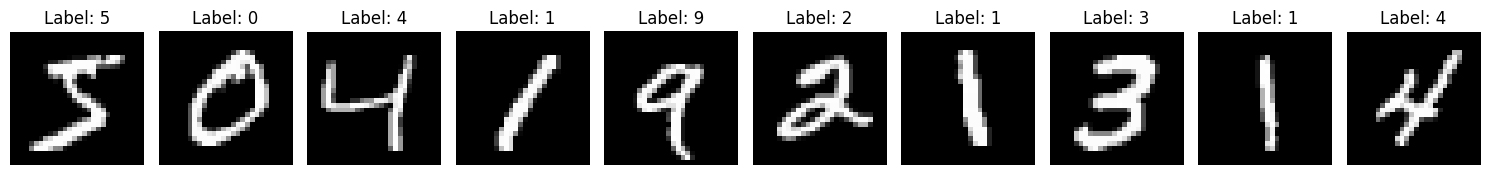

In [3]:
# Set the size of the overall figure (width=15 inches, height=3 inches)
plt.figure(figsize=(15, 3))

# Loop 10 times to display the first 10 images (index 0 to 9)
for i in range(10):
    # Create a subplot grid with 1 row and 10 columns; select the (i + 1)th position
    plt.subplot(1, 10, i + 1)

    # Display the ith training image. 'cmap="gray"' ensures it shows in grayscale
    plt.imshow(x_train[i], cmap="gray")

    # Set the title of each individual image to its corresponding correct label
    plt.title(f"Label: {y_train[i]}")

    # Hide the X and Y axis pixel coordinates to make the layout look clean
    plt.axis('off')

# Automatically adjust the spacing between subplots so they don't overlap
plt.tight_layout()

# Render and display the final row of images on the screen
plt.show()

In [4]:
# --- STEP 1: Check and Print Shapes Before Preprocessing ---
# Let's see what the data looks like right after loading it
print("--- BEFORE PREPROCESSING ---")
print("x_train shape:", x_train.shape)  # Expected: (60000, 28, 28)
print("x_test shape:", x_test.shape)    # Expected: (10000, 28, 28)
print("Data type before:", x_train.dtype)  # Usually uint8 (integers from 0 to 255)

# --- STEP 2: Normalize Pixel Values (0-255 to 0.0-1.0) ---
# We convert the integers to floats and divide by 255.0 to scale them down
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# --- STEP 3: Reshape Images for CNN Input ---
# CNNs expect a 4D tensor input: (batch_size, height, width, color_channels)
# Since MNIST is grayscale, it has exactly 1 color channel.
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

# --- STEP 4: Print Shapes After Preprocessing ---
# Let's verify that our dimensions and data types have successfully changed
print("\n--- AFTER PREPROCESSING ---")
print("x_train_cnn shape:", x_train_cnn.shape)  # Expected: (60000, 28, 28, 1)
print("x_test_cnn shape:", x_test_cnn.shape)    # Expected: (10000, 28, 28, 1)
print("Data type after:", x_train_cnn.dtype)    # Expected: float32

--- BEFORE PREPROCESSING ---
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
Data type before: uint8

--- AFTER PREPROCESSING ---
x_train_cnn shape: (60000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)
Data type after: float32


In [7]:
# Import the specific layer types we need from Keras
from tensorflow.keras import layers, models

# Initialize a Sequential model, which allows us to stack layers linearly one after the other
model = models.Sequential()

# 1. Conv2D Layer (Feature Extractor)
# Looks at 3x3 pixel windows to find 32 different unique patterns/edges.
# 'input_shape=(28, 28, 1)' tells the model the exact size of our preprocessed MNIST images.
# 'activation="relu"' keeps the math stable by turning negative numbers into zeros.
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)))

# 2. MaxPooling2D Layer (Downsampling)
# Looks at 2x2 grids and keeps only the maximum value.
# This cuts the image dimensions in half, reducing computational work and preventing overfitting.
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# 3. Second Conv2D Layer (Deep Feature Extractor)
# Takes the simplified patterns from the first layer and extracts 64 more complex features.
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))

# 4. Second MaxPooling2D Layer
# Shrinks the image dimensions in half once again.
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# --- Transition Phase ---
# 5. Flatten Layer
# Converts the 2D spatial feature grids into a long, 1D flat list of numbers.
# This prepares the data so it can be read by standard, fully connected neural network layers.
model.add(layers.Flatten())

# --- Classification Phase ---
# 6. Dense Layer (Hidden Layer)
# A fully connected layer with 128 neurons to connect and analyze all the flattened features.
model.add(layers.Dense(units=128, activation="relu"))

# 7. Output Dense Layer
# The final layer with 10 neurons (one for each digit from 0 to 9).
# 'activation="softmax"' turns the final outputs into probabilities that add up to 1 (e.g., 95% chance it's a '7').
model.add(layers.Dense(units=10, activation="softmax"))

# --- Verify the Architecture ---
# Print a complete breakdown table of the model's layers, output shapes, and parameters
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile the model by configuring its learning process
model.compile(
    # 1. Choose the optimization algorithm to update weights based on data
    optimizer='adam',

    # 2. Choose the loss function to measure how wrong the model's predictions are
    loss='sparse_categorical_crossentropy',

    # 3. Choose the metric we want to track during training and testing
    metrics=['accuracy']
)

print("Model compiled successfully and is ready for training!")

Model compiled successfully and is ready for training!


In [10]:
# Train the model using the fit() function and save the progress in 'history'
history = model.fit(
    # 1. Provide the preprocessed 4D training images and their matching labels
    x=x_train_cnn,
    y=y_train,

    # 2. Set the batch size to 32 (the model looks at 32 images before updating weights)
    batch_size=32,

    # 3. Train for 5 epochs (the model will go through the entire dataset 5 complete times)
    epochs=5,

    # 4. Display training progress in real-time (verbose=1 shows a progress bar for each epoch)
    verbose=1
)

print("\nTraining complete! The model's learning progress has been saved to the 'history' variable.")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9622 - loss: 0.1250
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9864 - loss: 0.0431
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9906 - loss: 0.0291
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9935 - loss: 0.0200
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9952 - loss: 0.0152

Training complete! The model's learning progress has been saved to the 'history' variable.


In [11]:
# Evaluate the model on the test dataset (images and labels it has never seen before)
# verbose=0 keeps the output clean by hiding the internal progress bars
test_loss, test_accuracy = model.evaluate(x=x_test_cnn, y=y_test, verbose=0)

# Print the final calculated test loss
print(f"Test Loss: {test_loss:.4f}")

# Print the final calculated test accuracy as a percentage
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0312
Test Accuracy: 99.09%


In [12]:
# UPDATE your previous training code to include validation data:
history = model.fit(
    x=x_train_cnn,
    y=y_train,
    batch_size=32,
    epochs=5,
    validation_data=(x_test_cnn, y_test), # This captures validation loss and accuracy!
    verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9888 - val_loss: 0.0420
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9906 - val_loss: 0.0366
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accuracy: 0.9919 - val_loss: 0.0356
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.9916 - val_loss: 0.0415
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 0.9917 - val_loss: 0.0377


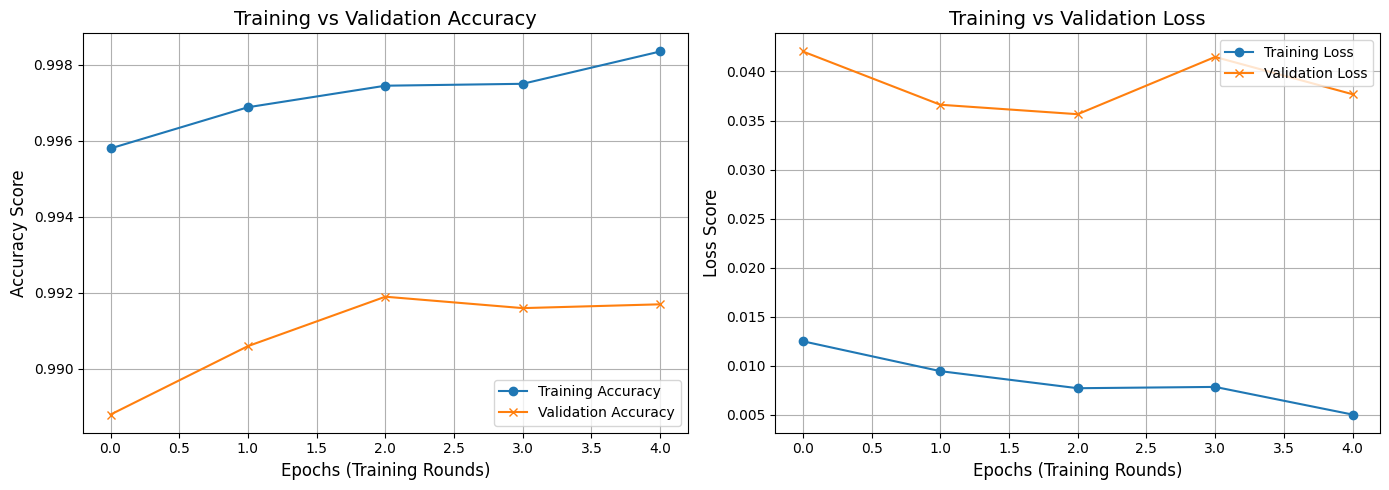

In [13]:
# Import matplotlib.pyplot to handle the graph plotting
import matplotlib.pyplot as plt

# Create a wide canvas figure to hold 2 subplots side-by-side (width=14 inches, height=5 inches)
plt.figure(figsize=(14, 5))

# --- 1. ACCURACY PLOT ---
# Define a grid of 1 row and 2 columns, and select the 1st subplot slot
plt.subplot(1, 2, 1)

# Plot training accuracy with circular markers ('o')
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')

# Plot validation accuracy with 'x' markers
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')

# Add clear titles and labels for the first graph
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs (Training Rounds)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)

# Place a legend box on the plot to help distinguish the lines
plt.legend(loc='lower right')

# Add a subtle grid background to make reading exact numbers easier
plt.grid(True)


# --- 2. LOSS PLOT ---
# Move to the 2nd subplot slot in our 1 row, 2 columns grid
plt.subplot(1, 2, 2)

# Plot training loss with circular markers ('o')
plt.plot(history.history['loss'], label='Training Loss', marker='o')

# Plot validation loss with 'x' markers
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')

# Add clear titles and labels for the second graph
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (Training Rounds)', fontsize=12)
plt.ylabel('Loss Score', fontsize=12)

# Place a legend box on the plot to help distinguish the lines
plt.legend(loc='upper right')

# Add a subtle grid background
plt.grid(True)


# Automatically optimize layout spacing so titles and labels don't overlap
plt.tight_layout()

# Save the final plot as an image file in your current directory
plt.savefig('cnn_training_performance.png')

# Render and display the side-by-side graphs inside your Google Colab notebook
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


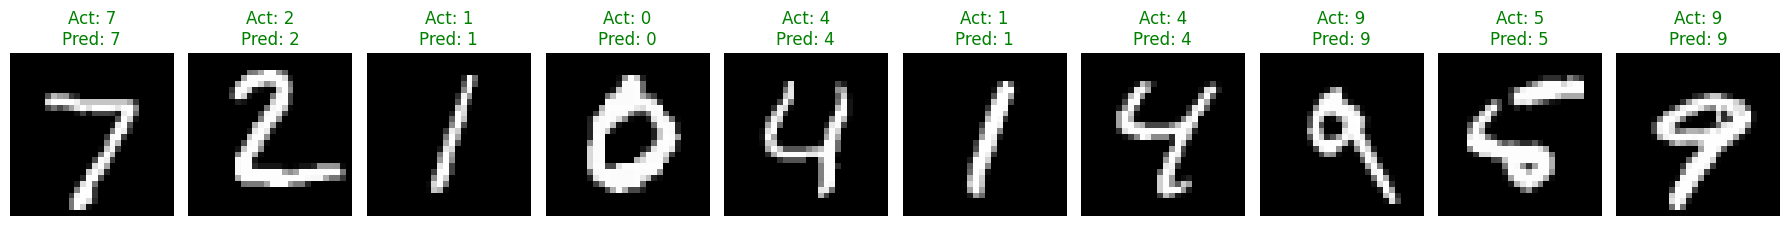

In [14]:
# --- STEP 1: Predict digits from test images ---
# Use the trained model to generate predictions for all test images.
# This outputs a matrix of probabilities (10 values per image).
predictions = model.predict(x_test_cnn)

# Create a wide canvas figure to display 10 images side-by-side
plt.figure(figsize=(18, 4))

# --- STEP 2: Display 10 test images along with labels ---
# We will loop through the first 10 images of the test dataset (index 0 to 9)
for i in range(10):
    # Setup a subplot grid with 1 row and 10 columns, selecting the (i + 1)th slot
    plt.subplot(1, 10, i + 1)

    # Reshape the 4D CNN input back to a 2D (28x28) shape for Matplotlib to display
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap="gray")

    # Extract the true label for this image
    actual_label = y_test[i]

    # Use np.argmax() to find the index with the highest probability value.
    # This index corresponds exactly to the digit the model thinks it sees.
    predicted_label = np.argmax(predictions[i])

    # Set the title to show both Actual and Predicted labels.
    # We will color the text green if correct, and red if the model made a mistake.
    if actual_label == predicted_label:
        color = "green"
    else:
        color = "red"

    # --- STEP 3 & 4: Show actual and predicted labels ---
    plt.title(f"Act: {actual_label}\nPred: {predicted_label}", color=color, fontsize=12)

    # Hide the pixel grid axes for a cleaner look
    plt.axis('off')

# Adjust spacing cleanly so text doesn't overlap
plt.tight_layout()

# Render the final visualization
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


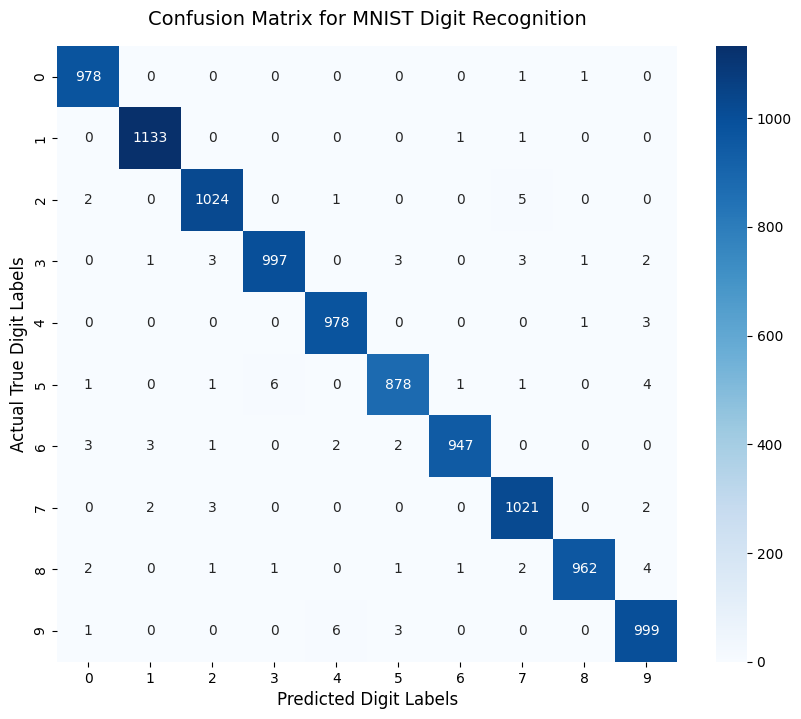

In [15]:
# Import the confusion matrix function from scikit-learn
from sklearn.metrics import confusion_matrix

# Import seaborn for creating a clean, professional heatmap visualization
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Get Model Predictions ---
# Get the raw probability distributions for the test dataset
raw_predictions = model.predict(x_test_cnn)

# Convert the raw probabilities into definitive class integer labels (0 to 9)
# by taking the index of the highest probability value for each image.
y_pred = np.argmax(raw_predictions, axis=1)

# --- STEP 2: Generate the Confusion Matrix Data ---
# Compare the true labels (y_test) against our model's guesses (y_pred)
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

# --- STEP 3: Plot the Heatmap ---
# Set up a square canvas size that fits a 10x10 matrix comfortably
plt.figure(figsize=(10, 8))

# Draw the heatmap using seaborn
# 'annot=True' displays the actual raw counts inside each square
# 'fmt="d"' forces formatting as integers instead of scientific notation
# 'cmap="Blues"' colors the matrix with varying shades of blue based on data density
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)))

# Add informative titles and axis labels to guide the reader
plt.title("Confusion Matrix for MNIST Digit Recognition", fontsize=14, pad=15)
plt.xlabel("Predicted Digit Labels", fontsize=12)
plt.ylabel("Actual True Digit Labels", fontsize=12)

# Render and show the complete graph
plt.show()

In [16]:
# --- STEP 1: Save the Trained Model ---
# We use the .h5 extension to save the model in the HDF5 format.
# This saves the model architecture, weights, and compilation settings.
model.save('mnist_cnn_model.h5')
print("Model saved successfully as 'mnist_cnn_model.h5'!")

# --- STEP 2: Load the Saved Model Later ---
# To demonstrate loading, we use Keras's load_model function.
# This can be done in a completely new notebook or script without rebuilding the architecture.
from tensorflow.keras.models import load_model

# Load the exact state of the trained model from the saved file
loaded_model = load_model('mnist_cnn_model.h5')
print("Model loaded successfully and is ready for predictions!")

# Verify the loaded model matches by printing its summary
loaded_model.summary()

Model saved successfully as 'mnist_cnn_model.h5'!
Model loaded successfully and is ready for predictions!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,036 (879.05 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

TensorFlow Version: 2.20.0

Visualizing the first 10 training images...


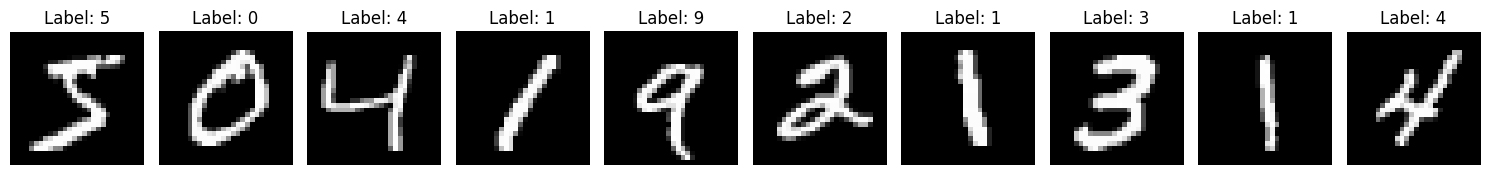


Shapes before preprocessing: Train=(60000, 28, 28), Test=(10000, 28, 28)
Shapes after preprocessing: Train=(60000, 28, 28, 1), Test=(10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9617 - loss: 0.1238 - val_accuracy: 0.9863 - val_loss: 0.0410
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9890 - val_loss: 0.0309
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9902 - val_loss: 0.0296
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.9915 - val_loss: 0.0269
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 0.9921 - val_loss: 0.0265

Evaluating model performance on unseen test data...
Final Test Loss: 0.0265
Final Test Accuracy: 99.21%


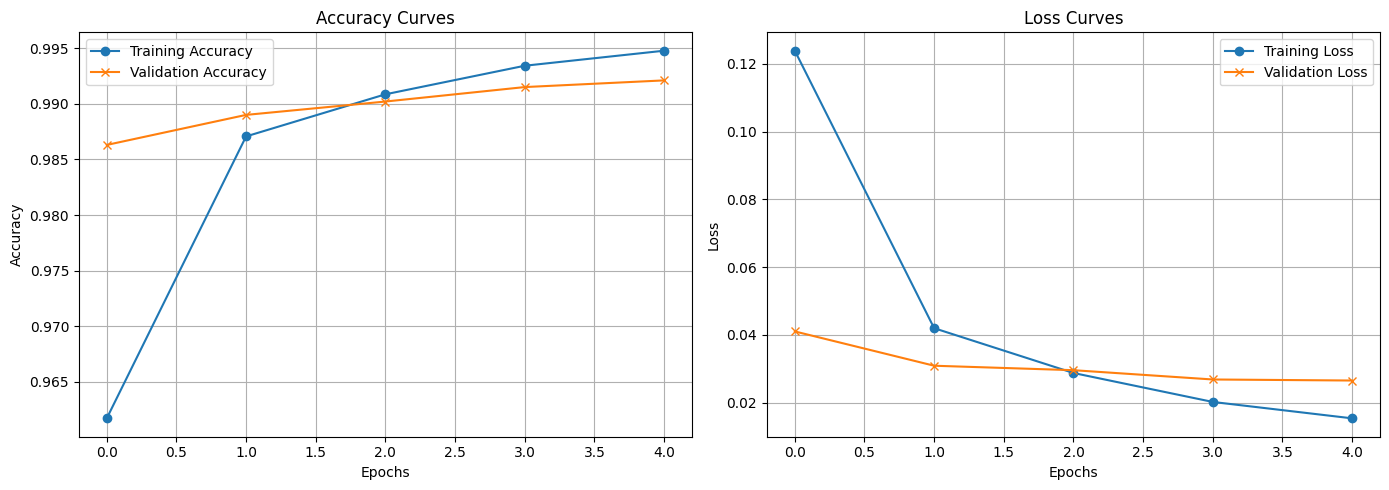


Generating model predictions on test samples...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


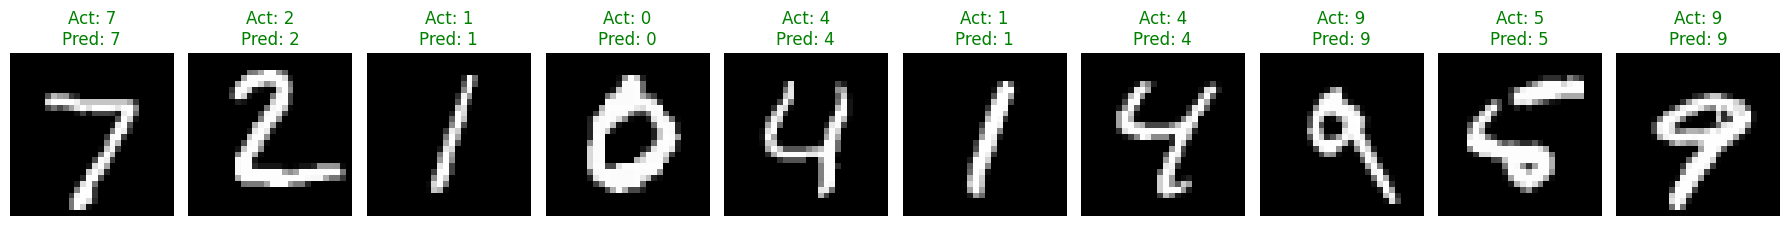


Generating confusion matrix...


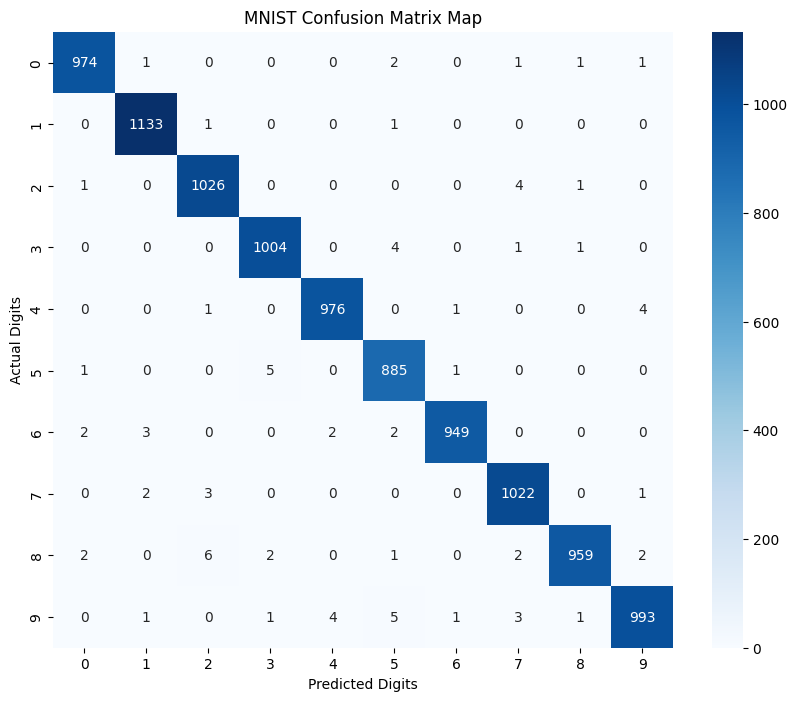


Workflow Complete! Model artifact saved as 'mnist_cnn_model.h5'


In [17]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 2: LOAD DATASET
# ==========================================
# Automatically split MNIST into training and testing components
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# ==========================================
# STEP 3: VISUALIZE DATASET
# ==========================================
print("\nVisualizing the first 10 training images...")
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 4: PREPROCESS DATA
# ==========================================
print(f"\nShapes before preprocessing: Train={x_train.shape}, Test={x_test.shape}")

# Normalize pixels to range [0.0, 1.0]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape datasets to 4D tensors for CNN compatibility (adds 1 grayscale channel)
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(f"Shapes after preprocessing: Train={x_train_cnn.shape}, Test={x_test_cnn.shape}")

# ==========================================
# STEP 5: BUILD CNN
# ==========================================
model = models.Sequential()

# Feature Extraction Layers
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# Flatten and Classification Layers
model.add(layers.Flatten())
model.add(layers.Dense(units=128, activation="relu"))
model.add(layers.Dense(units=10, activation="softmax"))

# Print architectural outline
model.summary()

# ==========================================
# STEP 6: COMPILE MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# STEP 7: TRAIN MODEL
# ==========================================
print("\nStarting model training...")
# Note: validation_data is included to feed the performance plotting step later
history = model.fit(
    x=x_train_cnn,
    y=y_train,
    batch_size=32,
    epochs=5,
    validation_data=(x_test_cnn, y_test),
    verbose=1
)

# ==========================================
# STEP 8: EVALUATE MODEL
# ==========================================
print("\nEvaluating model performance on unseen test data...")
test_loss, test_accuracy = model.evaluate(x=x_test_cnn, y=y_test, verbose=0)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# ==========================================
# STEP 9: PLOT RESULTS
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy Evolution
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss Evolution
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# STEP 10: MAKE PREDICTIONS
# ==========================================
print("\nGenerating model predictions on test samples...")
raw_predictions = model.predict(x_test_cnn)
y_pred = np.argmax(raw_predictions, axis=1)

# Visualize 10 test predictions
plt.figure(figsize=(18, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap="gray")

    color = "green" if y_test[i] == y_pred[i] else "red"
    plt.title(f"Act: {y_test[i]}\nPred: {y_pred[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# STEP 11: CONFUSION MATRIX
# ==========================================
print("\nGenerating confusion matrix...")
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)))
plt.title("MNIST Confusion Matrix Map")
plt.xlabel("Predicted Digits")
plt.ylabel("Actual Digits")
plt.show()

# ==========================================
# STEP 12: SAVE MODEL
# ==========================================
model.save('mnist_cnn_model.h5')
print("\nWorkflow Complete! Model artifact saved as 'mnist_cnn_model.h5'")

In [18]:
from google.colab import files

uploaded = files.upload()

Saving digit.png to digit.png


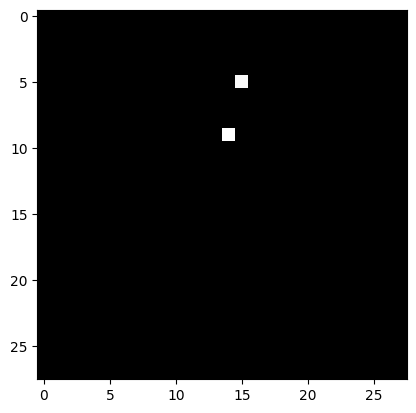

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "digit.png",
    color_mode="grayscale",
    target_size=(28, 28)
)

img_array = image.img_to_array(img)

plt.imshow(img_array.squeeze(), cmap="gray")
plt.show()

In [20]:
img_array = img_array / 255.0

In [21]:
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 28, 28, 1)


In [22]:
prediction = model.predict(img_array)

digit = np.argmax(prediction)

print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
Predicted Digit: 2


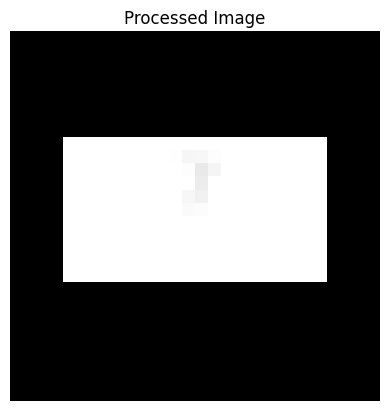

In [24]:
import numpy as np
from PIL import Image

# Load image in grayscale
img = Image.open("digit.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# If background is white and digit is black, invert
img_array = 255 - img_array

# Find non-zero pixels (the digit)
rows = np.any(img_array > 20, axis=1)
cols = np.any(img_array > 20, axis=0)

ymin, ymax = np.where(rows)[0][[0, -1]]
xmin, xmax = np.where(cols)[0][[0, -1]]

# Crop digit
cropped = img_array[ymin:ymax+1, xmin:xmax+1]

# Resize while maintaining aspect ratio
cropped_img = Image.fromarray(cropped)

max_size = 20  # digit occupies most of 28x28
cropped_img.thumbnail((max_size, max_size))

# Create 28x28 black canvas
canvas = Image.new("L", (28, 28), 0)

# Center digit
x_offset = (28 - cropped_img.width) // 2
y_offset = (28 - cropped_img.height) // 2

canvas.paste(cropped_img, (x_offset, y_offset))

# Convert for prediction
final_img = np.array(canvas) / 255.0
final_img = final_img.reshape(1, 28, 28, 1)

# Display processed image
import matplotlib.pyplot as plt

plt.imshow(final_img[0, :, :, 0], cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

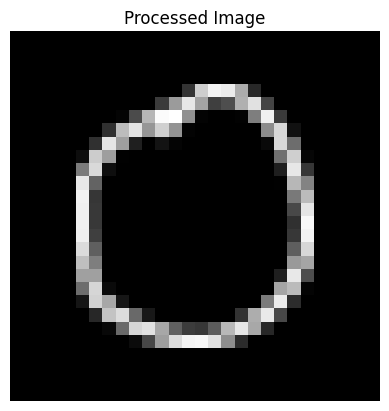

In [41]:
import numpy as np
from PIL import Image

# Load image in grayscale
img = Image.open("digit0.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# If background is white and digit is black, invert
# Removed: img_array = 255 - img_array

# Find non-zero pixels (the digit)
rows = np.any(img_array > 20, axis=1)
cols = np.any(img_array > 20, axis=0)

ymin, ymax = np.where(rows)[0][[0, -1]]
xmin, xmax = np.where(cols)[0][[0, -1]]

# Crop digit
cropped = img_array[ymin:ymax+1, xmin:xmax+1]

# Resize while maintaining aspect ratio
cropped_img = Image.fromarray(cropped)

max_size = 20  # digit occupies most of 28x28
cropped_img.thumbnail((max_size, max_size))

# Create 28x28 black canvas
canvas = Image.new("L", (28, 28), 0)

# Center digit
x_offset = (28 - cropped_img.width) // 2
y_offset = (28 - cropped_img.height) // 2

canvas.paste(cropped_img, (x_offset, y_offset))

# Convert for prediction
final_img = np.array(canvas) / 255.0
final_img = final_img.reshape(1, 28, 28, 1)

# Display processed image
import matplotlib.pyplot as plt

plt.imshow(final_img[0, :, :, 0], cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [42]:
prediction = model.predict(final_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Digit: 0


In [43]:
print("Predicted Digit:", np.argmax(prediction))

Predicted Digit: 0


In [27]:
for i, prob in enumerate(prediction[0]):
    print(f"Digit {i}: {prob:.4f}")

Digit 0: 0.0053
Digit 1: 0.0000
Digit 2: 0.0285
Digit 3: 0.0000
Digit 4: 0.9248
Digit 5: 0.0000
Digit 6: 0.0001
Digit 7: 0.0352
Digit 8: 0.0000
Digit 9: 0.0060


In [28]:
from google.colab import files

uploaded = files.upload()

Saving digit0.png to digit0.png


Let's first visualize the original `digit0.png` file as it was uploaded to ensure it looks like the digit you expect. Then, we can compare it with the model's prediction.

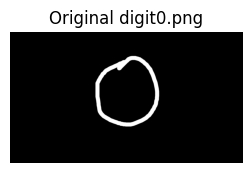

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the original image
original_img = Image.open("digit0.png")

# Display the original image
plt.figure(figsize=(3, 3))
plt.imshow(original_img, cmap="gray")
plt.title("Original digit0.png")
plt.axis("off")
plt.show()

In [44]:
from google.colab import files

uploaded = files.upload()

Saving digit1.png to digit1.png


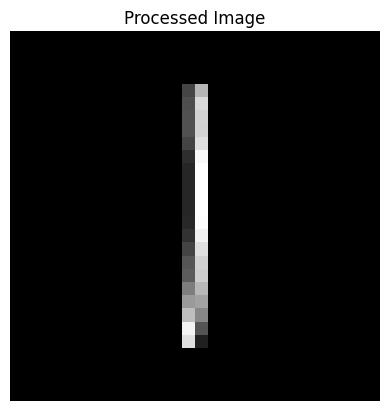

In [46]:
import numpy as np
from PIL import Image

# Load image in grayscale
img = Image.open("digit1.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# If background is white and digit is black, invert
# Removed: img_array = 255 - img_array

# Find non-zero pixels (the digit)
rows = np.any(img_array > 20, axis=1)
cols = np.any(img_array > 20, axis=0)

ymin, ymax = np.where(rows)[0][[0, -1]]
xmin, xmax = np.where(cols)[0][[0, -1]]

# Crop digit
cropped = img_array[ymin:ymax+1, xmin:xmax+1]

# Resize while maintaining aspect ratio
cropped_img = Image.fromarray(cropped)

max_size = 20  # digit occupies most of 28x28
cropped_img.thumbnail((max_size, max_size))

# Create 28x28 black canvas
canvas = Image.new("L", (28, 28), 0)

# Center digit
x_offset = (28 - cropped_img.width) // 2
y_offset = (28 - cropped_img.height) // 2

canvas.paste(cropped_img, (x_offset, y_offset))

# Convert for prediction
final_img = np.array(canvas) / 255.0
final_img = final_img.reshape(1, 28, 28, 1)

# Display processed image
import matplotlib.pyplot as plt

plt.imshow(final_img[0, :, :, 0], cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [47]:
prediction = model.predict(final_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Digit: 1


In [48]:
from google.colab import files

uploaded = files.upload()

Saving digit2.png to digit2.png


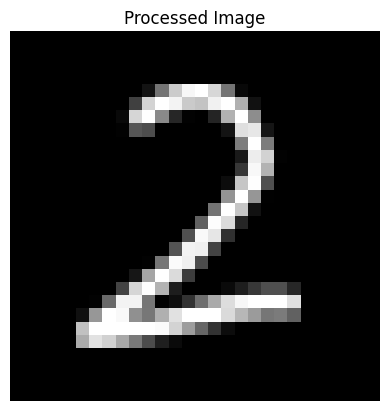

In [49]:
import numpy as np
from PIL import Image

# Load image in grayscale
img = Image.open("digit2.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# If background is white and digit is black, invert
# Removed: img_array = 255 - img_array

# Find non-zero pixels (the digit)
rows = np.any(img_array > 20, axis=1)
cols = np.any(img_array > 20, axis=0)

ymin, ymax = np.where(rows)[0][[0, -1]]
xmin, xmax = np.where(cols)[0][[0, -1]]

# Crop digit
cropped = img_array[ymin:ymax+1, xmin:xmax+1]

# Resize while maintaining aspect ratio
cropped_img = Image.fromarray(cropped)

max_size = 20  # digit occupies most of 28x28
cropped_img.thumbnail((max_size, max_size))

# Create 28x28 black canvas
canvas = Image.new("L", (28, 28), 0)

# Center digit
x_offset = (28 - cropped_img.width) // 2
y_offset = (28 - cropped_img.height) // 2

canvas.paste(cropped_img, (x_offset, y_offset))

# Convert for prediction
final_img = np.array(canvas) / 255.0
final_img = final_img.reshape(1, 28, 28, 1)

# Display processed image
import matplotlib.pyplot as plt

plt.imshow(final_img[0, :, :, 0], cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [50]:
prediction = model.predict(final_img)

predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Digit: 2
